# Sweep results — vc_comparison

Same as `sweep_results.ipynb`, pointed at the `vc_comparison` sweep. Globs every `model.metrics.jsonl` under `RESULTS_DIR`, parses each run's knobs out of its directory name (`cache__variant_head_pool_std_ws_lr_wd_ep`), and plots the chosen metrics over epochs — one figure per metric, one **panel per `FACET_BY`** value, one line per run (colored by `SERIES_BY`).

This sweep varies the cache (`vc` vs non-`vc`, snp-only vs not), so the **cache is the axis of interest** — set `FACET_BY = "cache"` to put each cache in its own panel. It auto-discovers runs, so re-run as more finish. Safe to run while the sweep is still going (partial last lines are tolerated).

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Root the sweep wrote heads under (relative to this notebook in train_pipeline/).
RESULTS_DIR = Path("../trained_heads/vc_comparison")

# (column in the jsonl, short label) for each metric to plot — one figure each.
METRICS = [
    ("val/mean_pcc",                    "mean PCC"),
    ("val/pcc/Panicle number per plant", "Panicle number PCC"),
]

# One panel per distinct value of this knob; one line per distinct combo of these.
# vc_comparison varies the cache, so 'cache' is the natural facet here.
FACET_BY   = "cache"
SERIES_BY  = ["variant", "head", "standardizer"]

## Discover + parse runs

Each run dir is `cache__variant_head_pool_std_ws_lr_wd_ep`. The cache tag itself contains underscores, so split on the `__` first, then positionally on the suffix. The cache column is shortened to whatever distinguishes the runs (the shared prefix is dropped, the base cache becomes `base`) for readable labels.

In [3]:
def load_metrics(path):
    """Read a JSONL sidecar into a DataFrame, tolerating a half-written last line."""
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(rows)

def parse_run(run_name):
    """cache__variant_head_pool_std_ws_lr_wd_ep -> dict of knobs."""
    cache, rest = run_name.split("__", 1)
    parts = rest.split("_")
    variant, head, pool, standardizer, ws = parts[:5]
    kv = {p[:2]: p[2:] for p in parts[5:]}   # lr1e-3 -> {'lr': '1e-3'}, etc.
    return {"cache": cache, "variant": variant, "head": head, "pool": pool,
            "standardizer": standardizer, "ws": ws,
            "lr": kv.get("lr"), "wd": kv.get("wd"), "ep": kv.get("ep")}

metrics_files = sorted(RESULTS_DIR.rglob("model.metrics.jsonl"))
runs = {}      # run_name -> {**knobs, 'df': DataFrame}
for p in metrics_files:
    run_name = p.parent.name
    runs[run_name] = {**parse_run(run_name), "df": load_metrics(p)}

info = pd.DataFrame({k: {c: v[c] for c in
                         ("cache", "variant", "head", "pool", "standardizer", "ws", "lr", "wd", "ep")}
                     for k, v in runs.items()}).T

# Shorten the cache tag by dropping the prefix common to every run (keeps labels short);
# the cache that IS that prefix becomes 'base'.
caches = info["cache"].unique().tolist()
if len(caches) > 1:
    common = caches[0]
    for c in caches[1:]:
        while not c.startswith(common):
            common = common[:-1]
    shorten = lambda c: c[len(common):].lstrip("_") or "base"
    info["cache"] = info["cache"].map(shorten)
    for name in runs:
        runs[name]["cache"] = shorten(runs[name]["cache"])

print(f"{len(runs)} runs under {RESULTS_DIR}")
for col in ("cache", "variant", "head", "standardizer", "ws", "lr", "wd", "ep"):
    print(f"  {col:13s}: {sorted(info[col].unique())}")

16 runs under ../trained_heads/vc_comparison
  cache        : ['hw500', 'hw500_snponly', 'vc_hw500', 'vc_hw500_snponly']
  variant      : ['centered']
  head         : ['linear', 'mlp']
  standardizer : ['perdim', 'rms']
  ws           : ['ws1']
  lr           : ['1e-3']
  wd           : ['1e-4']
  ep           : ['15']


## Final-epoch leaderboard

Best (max over epochs) validation PCC per run for each plotted metric, sorted by mean PCC. A quick way to see which configs won before reading the curves.

In [4]:
def best_val(df, col):
    if col not in df.columns:
        return np.nan
    s = df[col].dropna()
    return s.max() if len(s) else np.nan

board = info.copy()
for col, label in METRICS:
    board[f"best {label}"] = [best_val(runs[name]["df"], col) for name in board.index]
sort_col = f"best {METRICS[0][1]}"
board = board.sort_values(sort_col, ascending=False)
cols = ["cache", "variant", "head", "standardizer"] + [f"best {l}" for _, l in METRICS]
board[cols].round(3)

,cache,variant,head,standardizer,best mean PCC,best Panicle number PCC
sativas413_carbon500m_vc_hw500__centered_mlp_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,vc_hw500,centered,mlp,perdim,0.589,0.819
sativas413_carbon500m_hw500__centered_mlp_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,hw500,centered,mlp,perdim,0.587,0.791
sativas413_carbon500m_hw500_snponly__centered_mlp_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,hw500_snponly,centered,mlp,perdim,0.581,0.796
sativas413_carbon500m_vc_hw500_snponly__centered_mlp_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,vc_hw500_snponly,centered,mlp,perdim,0.579,0.793
sativas413_carbon500m_hw500__centered_mlp_sum_rms_ws1_lr1e-3_wd1e-4_ep15,hw500,centered,mlp,rms,0.574,0.788
sativas413_carbon500m_vc_hw500__centered_mlp_sum_rms_ws1_lr1e-3_wd1e-4_ep15,vc_hw500,centered,mlp,rms,0.574,0.819
sativas413_carbon500m_hw500__centered_linear_sum_rms_ws1_lr1e-3_wd1e-4_ep15,hw500,centered,linear,rms,0.549,0.812
sativas413_carbon500m_vc_hw500__centered_linear_sum_rms_ws1_lr1e-3_wd1e-4_ep15,vc_hw500,centered,linear,rms,0.545,0.807
sativas413_carbon500m_vc_hw500__centered_linear_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,vc_hw500,centered,linear,perdim,0.545,0.800
sativas413_carbon500m_hw500__centered_linear_sum_perdim_ws1_lr1e-3_wd1e-4_ep15,hw500,centered,linear,perdim,0.536,0.813


## Curves

One figure per metric, one panel per `FACET_BY` value, one line per run (val PCC over epoch). Color is consistent across all panels/figures (keyed on `SERIES_BY`) so a given config is the same color everywhere. `val/*` rows are logged once per epoch, so we drop the NaN train-only rows before plotting.

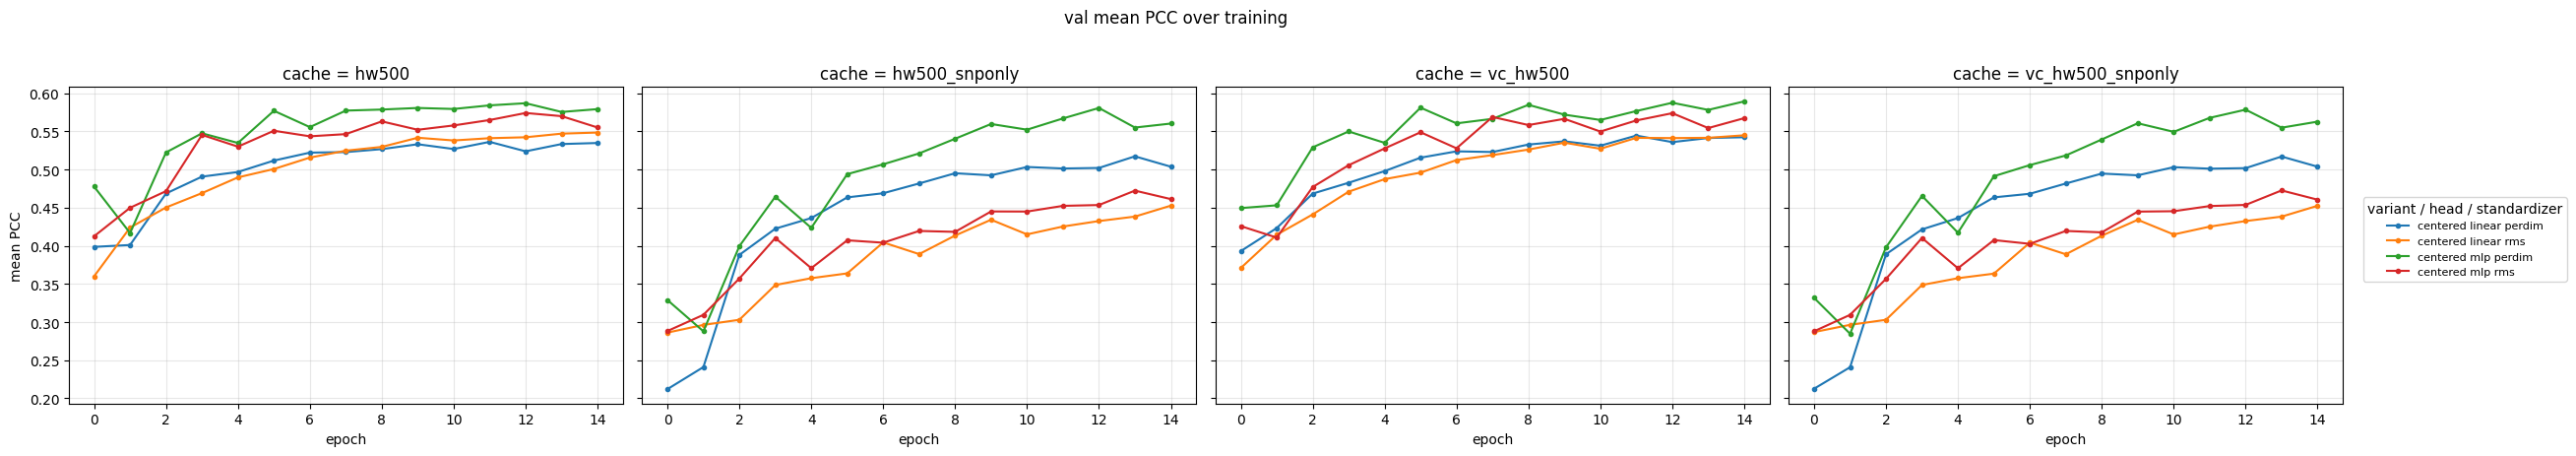

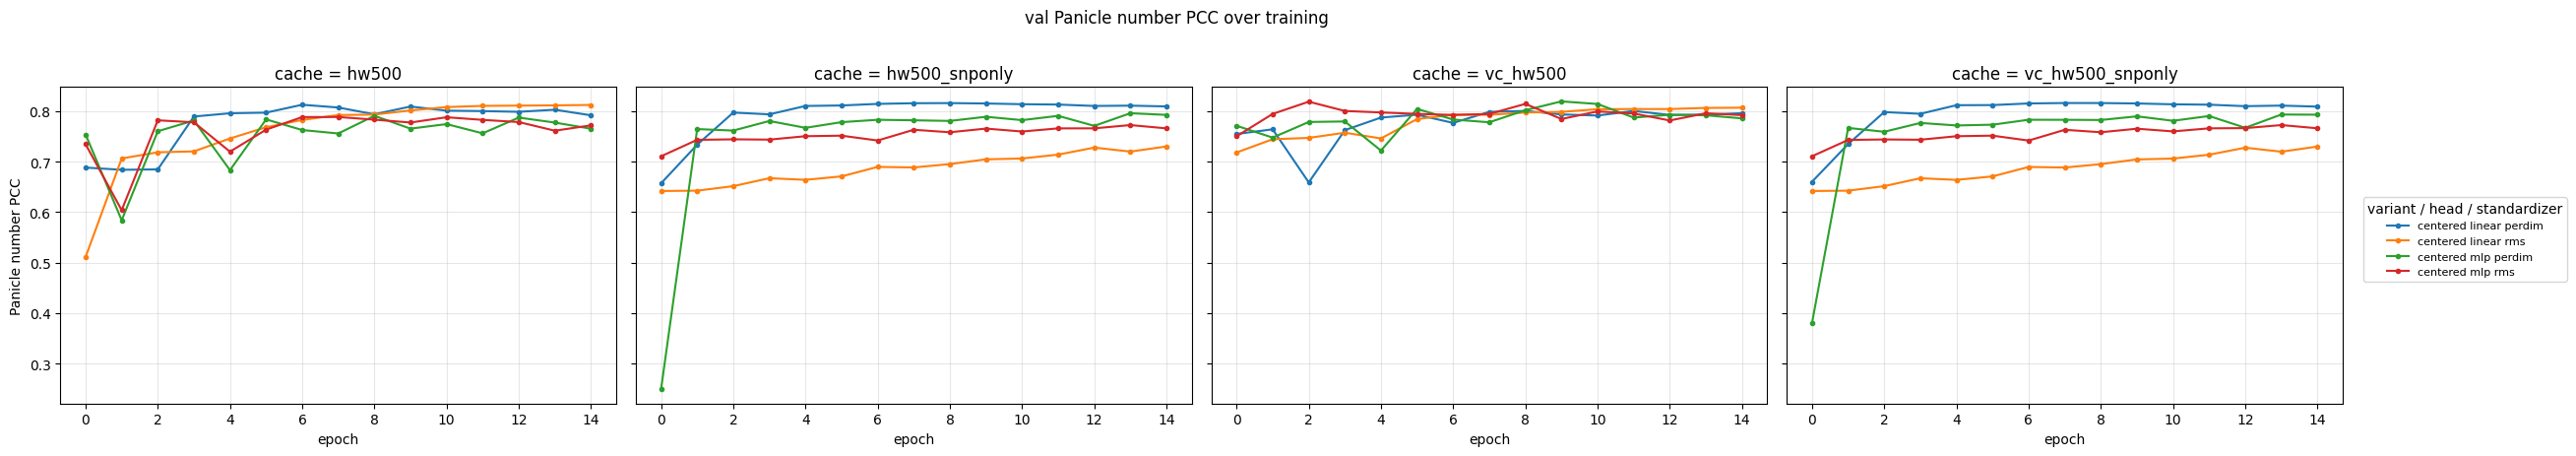

In [5]:
def series_label(meta):
    return " ".join(str(meta[c]) for c in SERIES_BY)

# Stable color per series label, shared across every panel and figure.
labels = sorted({series_label(m) for m in runs.values()})
cmap = plt.get_cmap("tab10" if len(labels) <= 10 else "tab20")
colors = {lab: cmap(i % cmap.N) for i, lab in enumerate(labels)}

def plot_metric(col, label):
    facets = sorted({m[FACET_BY] for m in runs.values()})
    fig, axes = plt.subplots(1, len(facets), figsize=(6 * len(facets), 4.5),
                             squeeze=False, sharey=True)
    for ax, facet in zip(axes[0], facets):
        for name, meta in runs.items():
            if meta[FACET_BY] != facet:
                continue
            df = meta["df"]
            if col not in df.columns:
                continue
            sub = df.dropna(subset=[col, "epoch"])
            if len(sub):
                lab = series_label(meta)
                ax.plot(sub["epoch"], sub[col], marker="o", ms=3,
                        color=colors[lab], label=lab)
        ax.set(xlabel="epoch", title=f"{FACET_BY} = {facet}")
        ax.grid(alpha=0.3)
    axes[0][0].set_ylabel(label)
    # One shared legend (series are identical across panels).
    handles, lbls = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc="center left", bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title=" / ".join(SERIES_BY))
    fig.suptitle(f"val {label} over training", y=1.02)
    fig.tight_layout()
    plt.show()

for col, label in METRICS:
    plot_metric(col, label)

## Eval traits over training

Every eval trait's validation PCC over epochs — rows are traits, columns are `FACET_BY` (cache), each line a run colored exactly as in the Curves cell. Traits absent from a run's metrics are skipped, and the legend is drawn from the full color map so it stays complete while the sweep is still running. Edit `EVAL_TRAITS` to change the set.

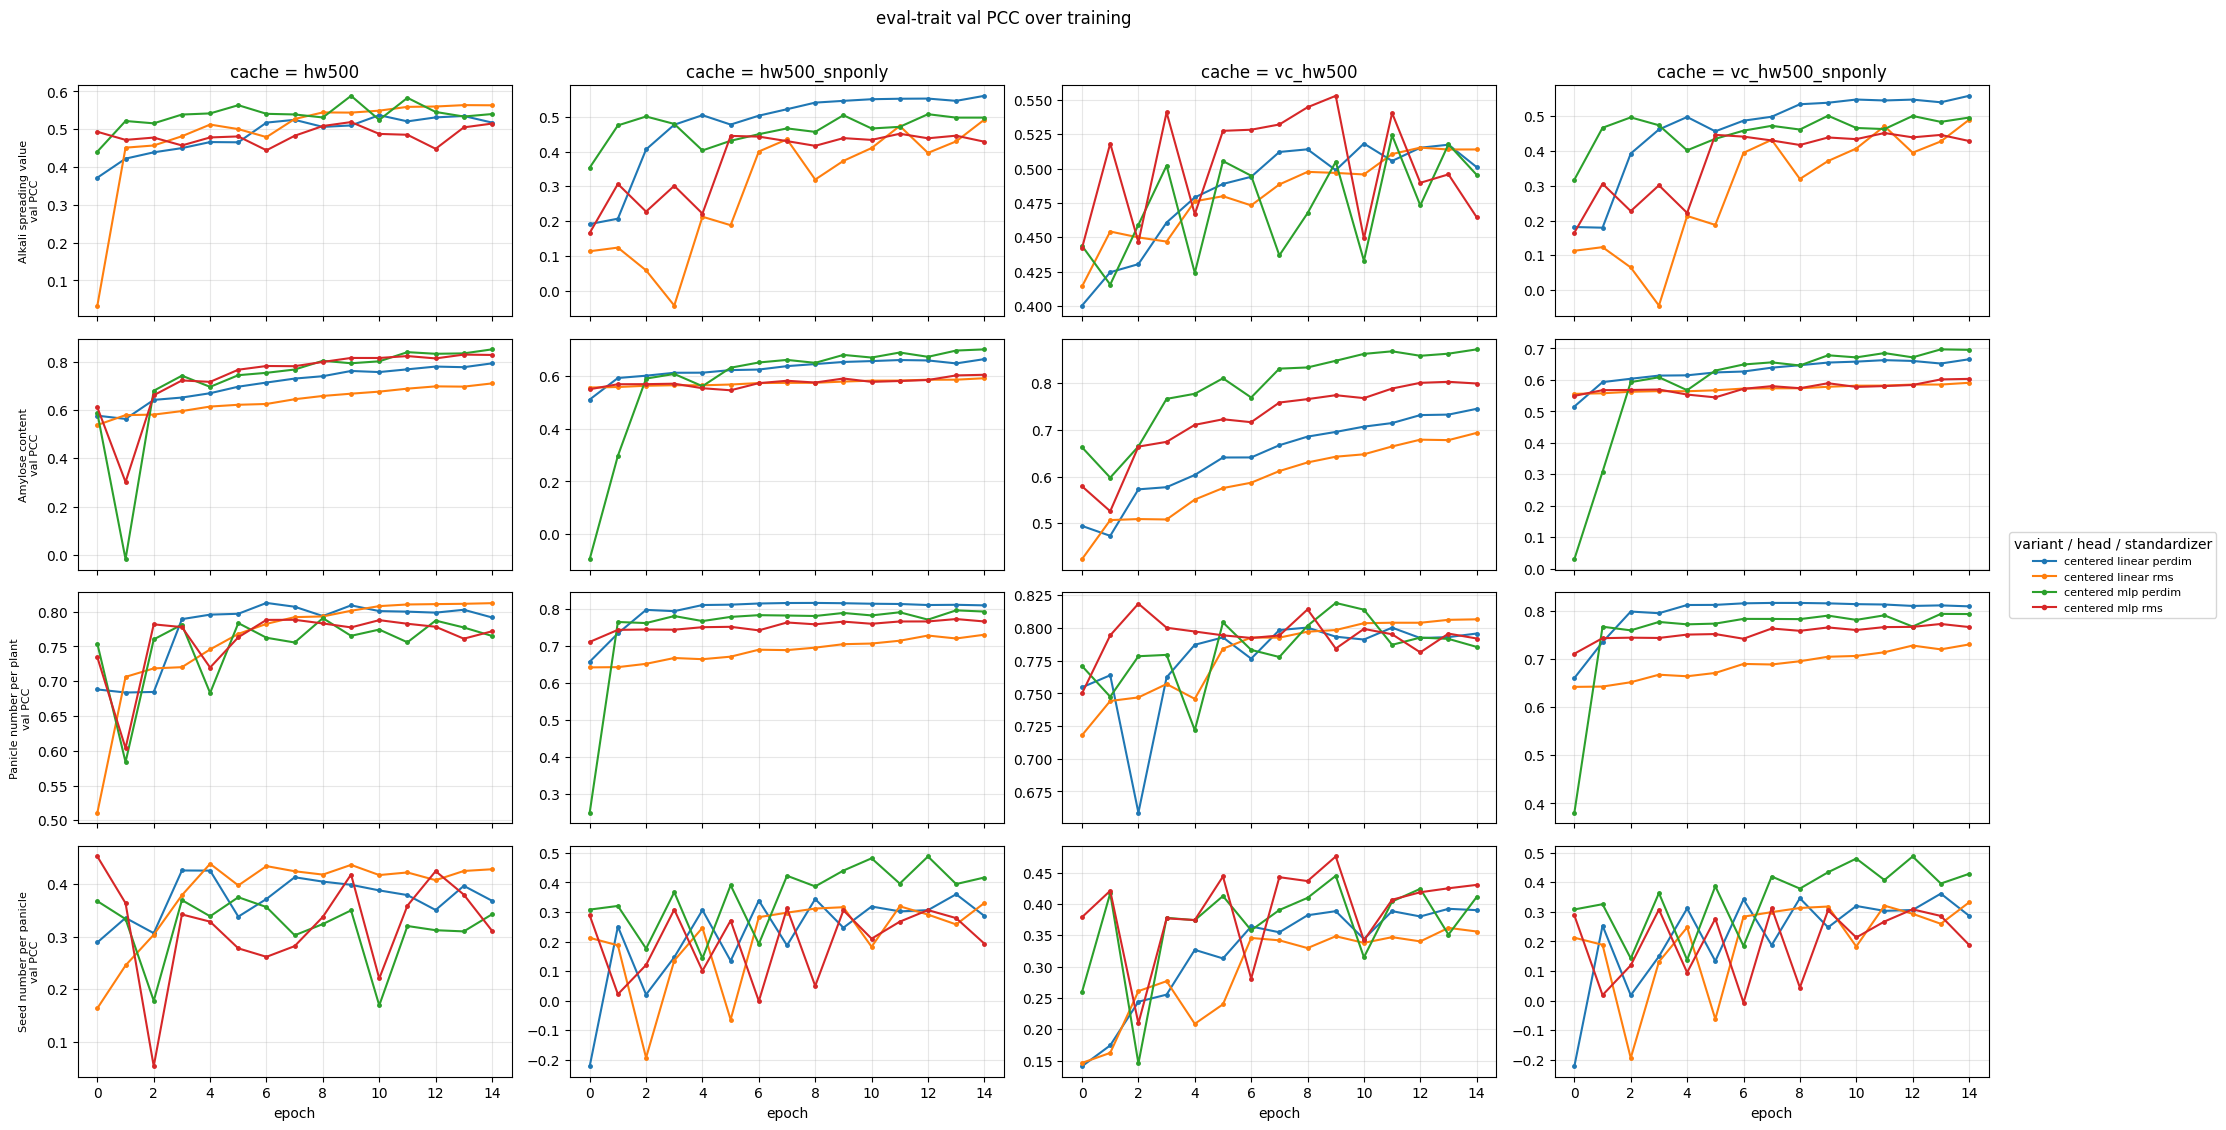

In [7]:
# All eval traits — val PCC over training. Rows = trait, cols = FACET_BY value;
# reuses the same per-series colors as the Curves cell above.
from matplotlib.lines import Line2D

EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    # "Protein content",
    # "Seed length",
    "Seed number per panicle",
]

def plot_eval_traits(traits=EVAL_TRAITS):
    facets = sorted({m[FACET_BY] for m in runs.values()})
    fig, axes = plt.subplots(len(traits), len(facets),
                             figsize=(5 * len(facets), 2.8 * len(traits)),
                             squeeze=False, sharex=True)
    for r, trait in enumerate(traits):
        col = f"val/pcc/{trait}"
        for c, facet in enumerate(facets):
            ax = axes[r][c]
            for meta in runs.values():
                if meta[FACET_BY] != facet:
                    continue
                df = meta["df"]
                if col not in df.columns:
                    continue
                sub = df.dropna(subset=[col, "epoch"])
                if len(sub):
                    ax.plot(sub["epoch"], sub[col], marker="o", ms=2.5,
                            color=colors[series_label(meta)])
            ax.grid(alpha=0.3)
            if r == 0:
                ax.set_title(f"{FACET_BY} = {facet}")
            if c == 0:
                ax.set_ylabel(f"{trait}\nval PCC", fontsize=8)
    for ax in axes[-1]:
        ax.set_xlabel("epoch")
    # Stable, complete legend from the global color map (robust while runs are partial).
    proxies = [Line2D([0], [0], color=colors[l], marker="o", ms=3) for l in labels]
    fig.legend(proxies, labels, loc="center left", bbox_to_anchor=(1.0, 0.5),
               fontsize=8, title=" / ".join(SERIES_BY))
    fig.suptitle("eval-trait val PCC over training", y=1.005)
    fig.tight_layout()
    plt.show()

plot_eval_traits()